# Regression Models and Metrics - Rachel Wantuch

In [300]:
import pandas as pd

df=pd.read_csv("auto-mpg.csv")

In [302]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## Remove 'car name' column

In [305]:
df_new=df.drop('car name', axis=1)
df_new.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


## Switch 'horsepower' column strings with column mean

In [308]:
df_new['horsepower'].dtype

dtype('O')

In [310]:
# Convert from string to float. I would do int but if we are going for the mean I feel like its going to return a float.\
df_new['horsepower']=pd.to_numeric(df_new['horsepower'], errors='coerce')

In [312]:
#Then use the replace() function to switch the ? with the mean
df_new['horsepower'].fillna(df_new['horsepower'].mean(), inplace=True)

C:\Users\rwant\AppData\Local\Temp\ipykernel_10076\535431798.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new['horsepower'].fillna(df_new['horsepower'].mean(), inplace=True)


## Create dummy variables for 'origin' column

In [315]:
df_new['origin'].value_counts()
#1=American, 2=European, 3=Japanese

origin
1    249
3     79
2     70
Name: count, dtype: int64

In [317]:
df=pd.get_dummies(df_new, columns=['origin'], dtype=int)
# to make it return integers isntead of T/F dtype=int

## Create a Correlation Coefficient Matrix

In [320]:
# You can do this with numpy or with pandas
corr_matrix=df.corr()
print(corr_matrix)

                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.775396     -0.804203   -0.771437 -0.831741   
cylinders    -0.775396   1.000000      0.950721    0.838939  0.896017   
displacement -0.804203   0.950721      1.000000    0.893646  0.932824   
horsepower   -0.771437   0.838939      0.893646    1.000000  0.860574   
weight       -0.831741   0.896017      0.932824    0.860574  1.000000   
acceleration  0.420289  -0.505419     -0.543684   -0.684259 -0.417457   
model year    0.579267  -0.348746     -0.370164   -0.411651 -0.306564   
origin_1     -0.568192   0.604351      0.651407    0.486083  0.598398   
origin_2      0.259022  -0.352861     -0.373886   -0.281258 -0.298843   
origin_3      0.442174  -0.396479     -0.433505   -0.321325 -0.440817   

              acceleration  model year  origin_1  origin_2  origin_3  
mpg               0.420289    0.579267 -0.568192  0.259022  0.442174  
cylinders        -0.505419   -0.348746  0.604351 -0.35

Are there feautres highly correlated with mpg?

There are many features that negatively affect mpg (cylinders, displacement, horsepower, weight). All those features have at least -0.7 values. Basically if its big like a truck its going to have low mpg.

Of the remaining features nothing improves mpg like the features that decrease mpg. The feautres range from 0.42 to 0.58 showing that they are not strong features that affect mpg but they do affect it somewhat.

## Plot mpg vs weight. Explain how it relates to the corresponding correlation coefficient.

In [324]:
## This will be a scatterplot
import matplotlib.pyplot as plt
import numpy as np

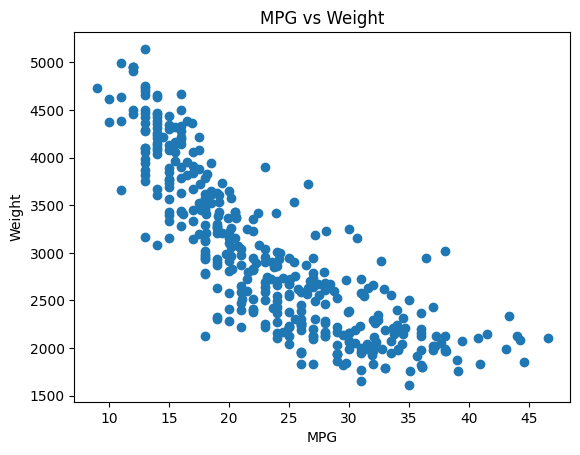

In [326]:
plt.scatter(df['mpg'], df['weight'])
plt.title("MPG vs Weight")
plt.xlabel("MPG")
plt.ylabel("Weight")
plt.show()

The graph is showing exactly what the corresponding correlation coefficients told us. Specifically around the 20 mpg mark anything with less MPG is on a more vertical line than anything with more than 20mpg. There are a few standout cars between 25-40 mpg that stand out as heavier than the rest but with just as good of mpg. After 40 mpg the field thins out byt stays around 2000 lbs for weight.

## Randomly split the data into 80% training/20% test data. Target=mpg

In [330]:
from sklearn.model_selection import train_test_split

In [351]:
x=df.drop(columns=['mpg'])
y=df['mpg']

In [353]:
x.head()

,cylinders,displacement,horsepower,weight,acceleration,model year,origin_1,origin_2,origin_3
0,8,307.0,130.0,3504,12.0,70,1,0,0
1,8,350.0,165.0,3693,11.5,70,1,0,0
2,8,318.0,150.0,3436,11.0,70,1,0,0
3,8,304.0,150.0,3433,12.0,70,1,0,0
4,8,302.0,140.0,3449,10.5,70,1,0,0


In [355]:
x.shape

(398, 9)

In [357]:
y.shape

(398,)

In [359]:
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

In [361]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

## Train an ordinary linear regression model on the training data

In [364]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Calculate R2, RMSE, and MAE on both the training and the test sets and interpret your results
### R2
#### Training

In [367]:
from sklearn.metrics import r2_score
y_pred_train=model.predict(x_train)
r2_train=r2_score(y_train,y_pred_train)
print(r2_train)

0.8188288951042786


#### Test

In [370]:
y_pred_test=model.predict(x_test)
r2_test=r2_score(y_test,y_pred_test)
print(r2_test)

0.8449006123776617


#### Interpretation
To start off from what I have gathered it is a little different that the test data R2 is larger than the training data R2. It is not larger by a huge amount though. Regardless of the difference both are above 0.8 indicating its good at predicting mpg even though this qualifies as underfitting a little bit.

## RMSE
### Training

In [374]:
from sklearn.metrics import root_mean_squared_error as RMSE
y_pred_train=model.predict(x_train)
rmse_train=RMSE(y_train,y_pred_train)
print(rmse_train)

3.370273563938906


### Test

In [377]:
y_pred_test=model.predict(x_test)
rmse_test=RMSE(y_test,y_pred_test)
print(rmse_test)

2.8877573478836305


#### Interpretation
The RMSE for train vs test is the same story. The test data performed better than the training data. There is less error showing up in the test data which came in at 2.89 roughly. The training data came n at 3.37 which translates to being 3.37 mpg away from the training data it was performed on. This shows underfitting or perhaps a need to look at the parameters or features used.

## MAE
### Training

In [381]:
from sklearn.metrics import mean_absolute_error as MAE
y_pred_train=model.predict(x_train)
mae_train=MAE(y_train,y_pred_train)
print(mae_train)

2.605484693771036


### Test

In [384]:
y_pred_test=model.predict(x_test)
mae_test=MAE(y_test,y_pred_test)
print(mae_test)

2.2875867704421053


#### Interpretation
Again the same pattern shows up here where the model performed better on the test set. The test set returned a value showing that the average absolute difference between the predicted and actual values was 2.29 roughly. Given the range of mpg we have I would say this result is good if you end up using either the training or test set just that there is room to improve the model. Our test set may be too small is what I'm thinking.

# Ridge Regression
The results didn't change much using ridge regression which after doing all of this makes sense since our linear regression was showing the model underfit was a problem. Ridge regression addresses overfitting more so thats why didnt see improvement here.

In [387]:
from sklearn.linear_model import Ridge
ridge_model=Ridge(alpha=0.1)
ridge_model.fit(x_train,y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


## Calculate R2, RMSE, and MAE on both the training and the test data
### R2
### Training

In [390]:
y_pred_train=ridge_model.predict(x_train)
r2_train=r2_score(y_train,y_pred_train)
print(r2_train)

0.8188288474333405


### Test

In [393]:
y_pred_test=ridge_model.predict(x_test)
r2_train=r2_score(y_test,y_pred_test)
print(r2_train)

0.8448991814595315


### RMSE
### Training

In [396]:
y_pred_train=model.predict(x_train)
rmse_train=RMSE(y_train,y_pred_train)
print(rmse_train)

3.370273563938906


### Test

In [399]:
y_pred_test=model.predict(x_test)
rmse_test=RMSE(y_test,y_pred_test)
print(rmse_test)

2.8877573478836305


### MAE
### Training

In [402]:
y_pred_train=model.predict(x_train)
mae_train=MAE(y_train,y_pred_train)
print(mae_train)

2.605484693771036


### Test

In [287]:
y_pred_test=model.predict(x_test)
mae_test=MAE(y_test,y_pred_test)
print(mae_test)

2.2875867704421053


# Polynomial Regression

THis regression model showed improvement in R2. Not only did it increase the training data came in slightly higher than the test data R2 which I think is more characteristic.

As far as the RMSE it does have an issue with the test data having a lower RMSE even though it is not by much. I suspect in this case whats going on is the size of the dataset but I am not sure. OVerall though the RMSE improved from the other two models so I would pick polynmial regression.

Lastly as far as the MAE goes the test MAE is still lower than the training data. After some research it seems good that the model wroked better on the test data but thats not norma. It just means that Its generalizing well.. The actual values were lower than linear regression and ridge regression so I would again choose Polynomial Regression.

In [420]:
from sklearn.preprocessing import PolynomialFeatures

In [440]:
poly=PolynomialFeatures(degree=2, include_bias=False)
x_train_poly=poly.fit_transform(x)
x_train,x_test,y_train,y_test= train_test_split(x_train_poly,y,test_size=0.2,random_state=42)

In [442]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## R2

In [444]:
y_pred_train=model.predict(x_train)
r2_train=r2_score(y_train,y_pred_train)
print(r2_train)

0.8991358610998542


In [446]:
y_pred_test=model.predict(x_test)
r2_train=r2_score(y_test,y_pred_test)
print(r2_train)

0.8945181848487167


## RMSE

In [449]:
y_pred_train=model.predict(x_train)
r2_train=RMSE(y_train,y_pred_train)
print(r2_train)

2.5147167814040117


In [451]:
y_pred_test=model.predict(x_test)
r2_train=RMSE(y_test,y_pred_test)
print(r2_train)

2.38146637200263


## MAE

In [456]:
y_pred_train=model.predict(x_train)
mae_train=MAE(y_train,y_pred_train)
print(mae_train)

1.8253166893052628


In [458]:
y_pred_test=model.predict(x_test)
mae_test=MAE(y_test,y_pred_test)
print(mae_test)

1.7498402686601622
